In [ ]:
# importing require library for performing EDA, Data Wrangling and data cleaning
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# importing customer churn analysis dataset csv file using pandas
df=pd.read_csv('Telecom_customer_churn.csv')

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.drop(['customerID'],axis=1,inplace=True)

In [ ]:
df['SeniorCitizen']=df['SeniorCitizen'].astype(object)

In [ ]:
#data integrity check
# since dataset is large, let check for any entry which is repeated or duplicated in dataset
df.duplicated().sum()

np.int64(22)

In [ ]:
#we can see 22 duplicate entry in dataset. let drop duplicate entry from dataset
df.drop_duplicates(keep='last',inplace=True)

In [ ]:
df.shape

(7021, 20)

In [ ]:
df['TotalCharges'].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [ ]:
#now check for whitespaces, NA,'-' in dataset
df[df['TotalCharges'].isin([' ','NA','-'])==True]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [ ]:
# there is possibility of whitespaces with null values
df['TotalCharges']=df['TotalCharges'].replace(' ',np.nan)

In [ ]:
df['TotalCharges']=df['TotalCharges'].astype(float)

In [ ]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
Numerical=df.select_dtypes(exclude='object')
Categorical=df.select_dtypes(include='object')

In [ ]:
for i in Categorical:
  print(i)
  print(df[i].value_counts())
  print('='*100)

gender
gender
Male      3535
Female    3475
Name: count, dtype: int64
SeniorCitizen
SeniorCitizen
0    5869
1    1141
Name: count, dtype: int64
Partner
Partner
No     3617
Yes    3393
Name: count, dtype: int64
Dependents
Dependents
No     4911
Yes    2099
Name: count, dtype: int64
PhoneService
PhoneService
Yes    6330
No      680
Name: count, dtype: int64
MultipleLines
MultipleLines
No                  3363
Yes                 2967
No phone service     680
Name: count, dtype: int64
InternetService
InternetService
Fiber optic    3090
DSL            2414
No             1506
Name: count, dtype: int64
OnlineSecurity
OnlineSecurity
No                     3489
Yes                    2015
No internet service    1506
Name: count, dtype: int64
OnlineBackup
OnlineBackup
No                     3079
Yes                    2425
No internet service    1506
Name: count, dtype: int64
DeviceProtection
DeviceProtection
No                     3086
Yes                    2418
No internet service    1506
N

In [ ]:
Categorical.shape

(7010, 17)

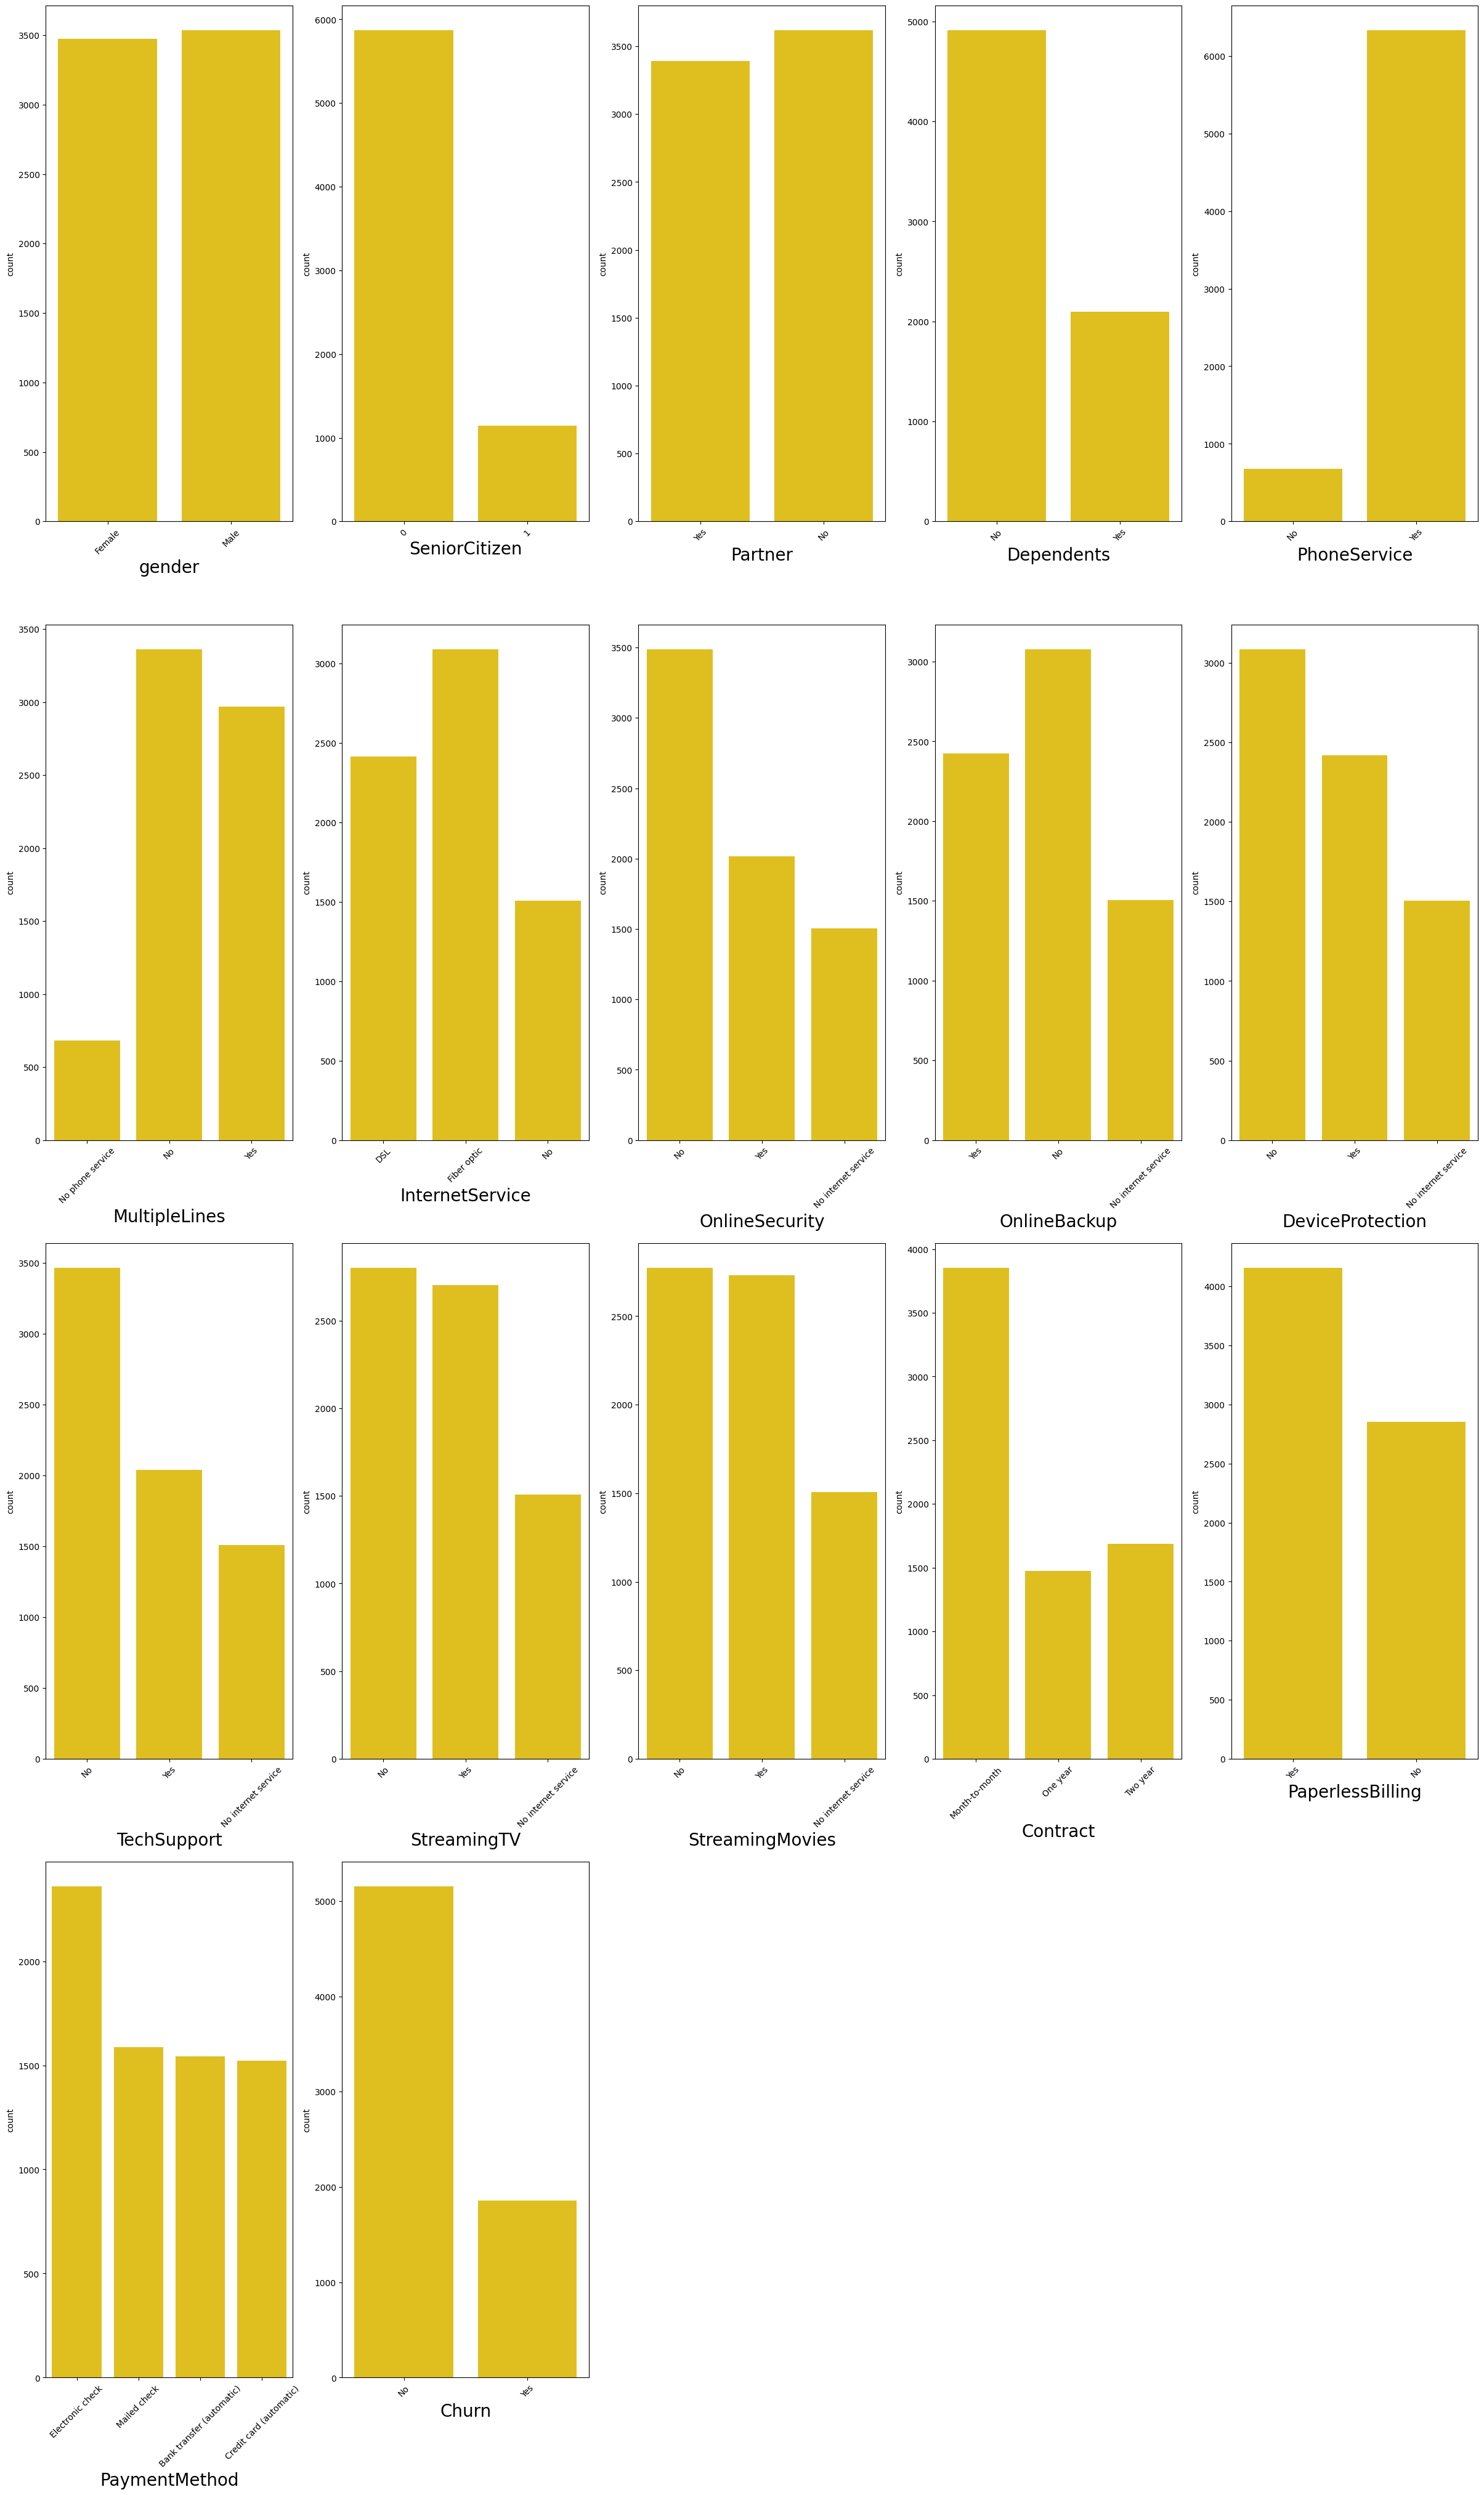

In [ ]:
sns.set_palette('hsv')
plt.figure(figsize=(30,50),facecolor='white')
plotnumber=1
for i in Categorical:
  if plotnumber<=17:
    ax=plt.subplot(4,5,plotnumber)
    sns.countplot(x=df[i])
    plt.xlabel(i,fontsize=20)
    plt.xticks(rotation=45)
  plotnumber=plotnumber+1
plt.show()

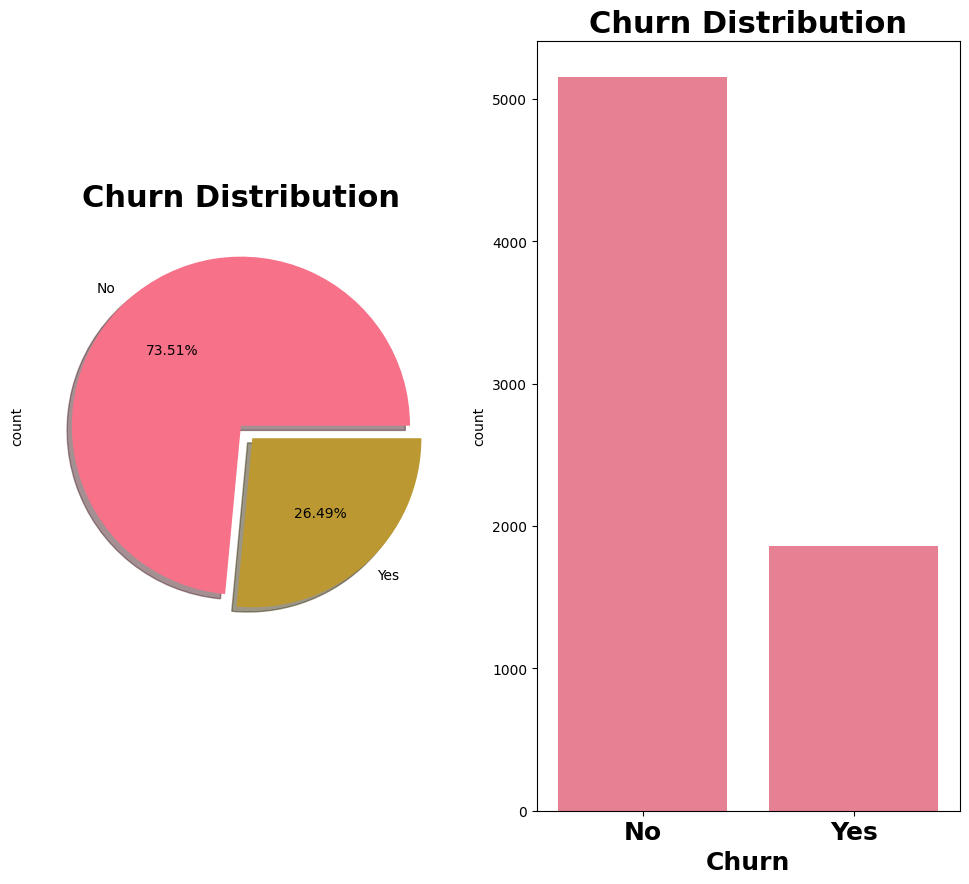

In [ ]:
sns.set_palette('husl')
plt.figure(figsize=(12,10))
plt.subplot(1,2,1)
df['Churn'].value_counts().plot.pie(explode=[0,0.1],autopct='%1.2f%%',shadow=True)
plt.title('Churn Distribution',fontsize=22,fontweight='bold')
plt.subplot(1,2,2)
sns.countplot(x='Churn',data=df)
plt.title('Churn Distribution',fontsize=22,fontweight='bold')
plt.xlabel('Churn',fontsize=18,fontweight='bold')
plt.xticks(fontsize=18,fontweight='bold')
plt.show()

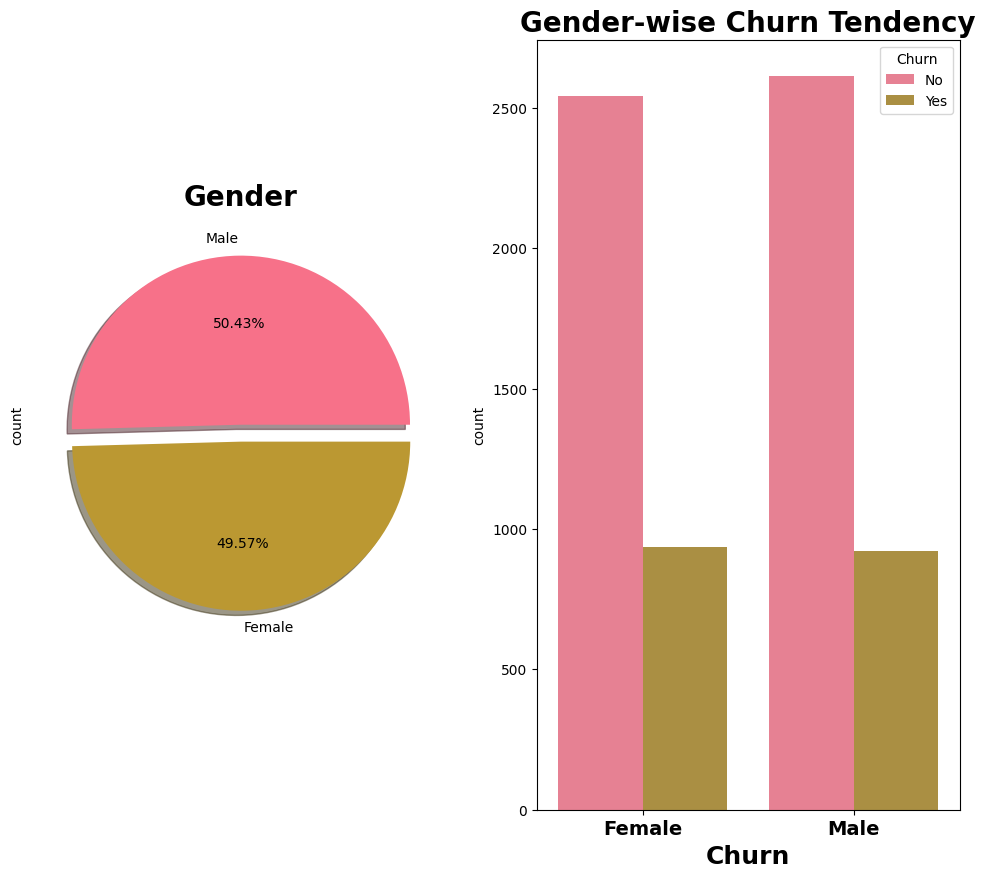

In [ ]:
#gender vs churn
sns.set_palette('husl')
plt.figure(figsize=(12,10))
plt.subplot(1,2,1)
df['gender'].value_counts().plot.pie(explode=[0,0.1],autopct='%1.2f%%',shadow=True)
plt.title('Gender',fontsize=20,fontweight='bold')
plt.subplot(1,2,2)
sns.countplot(x='gender',hue='Churn',data=df)
plt.title('Gender-wise Churn Tendency',fontsize=20,fontweight='bold')
plt.xlabel('Churn',fontsize=18,fontweight='bold')
plt.xticks(fontsize=14,fontweight='bold')
plt.show()

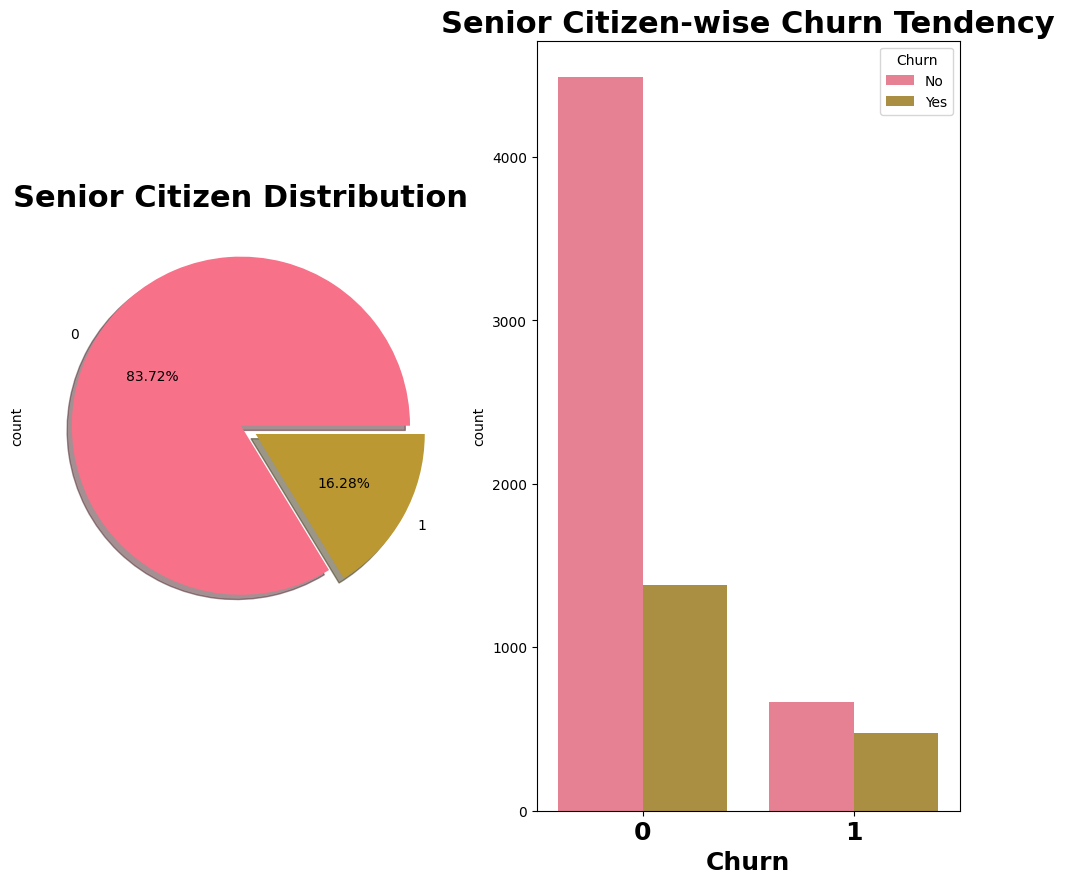

In [ ]:
#senior citizen vs churn
sns.set_palette('husl')
plt.figure(figsize=(12,10))
plt.subplot(1,2,1)
df['SeniorCitizen'].value_counts().plot.pie(explode=[0,0.1],autopct='%1.2f%%',shadow=True)
plt.title('Senior Citizen Distribution',fontsize=22,fontweight='bold')
plt.subplot(1,2,2)
sns.countplot(x='SeniorCitizen',hue='Churn',data=df)
plt.title('Senior Citizen-wise Churn Tendency',fontsize=22,fontweight='bold')
plt.xlabel('Churn',fontsize=18,fontweight='bold')
plt.xticks(fontsize=18,fontweight='bold')
plt.show()

In [ ]:
pd.crosstab([df.gender,df.SeniorCitizen],df['Churn'],margins=True)

Churn                   No   Yes   All
gender SeniorCitizen                  
Female 0              2213   695  2908
       1               328   239   567
Male   0              2274   687  2961
       1               338   236   574
All                   5153  1857  7010

In [ ]:
pd.crosstab([df.gender,df.SeniorCitizen],df['Churn'],margins=True).style.background_gradient(cmap='summer_r')

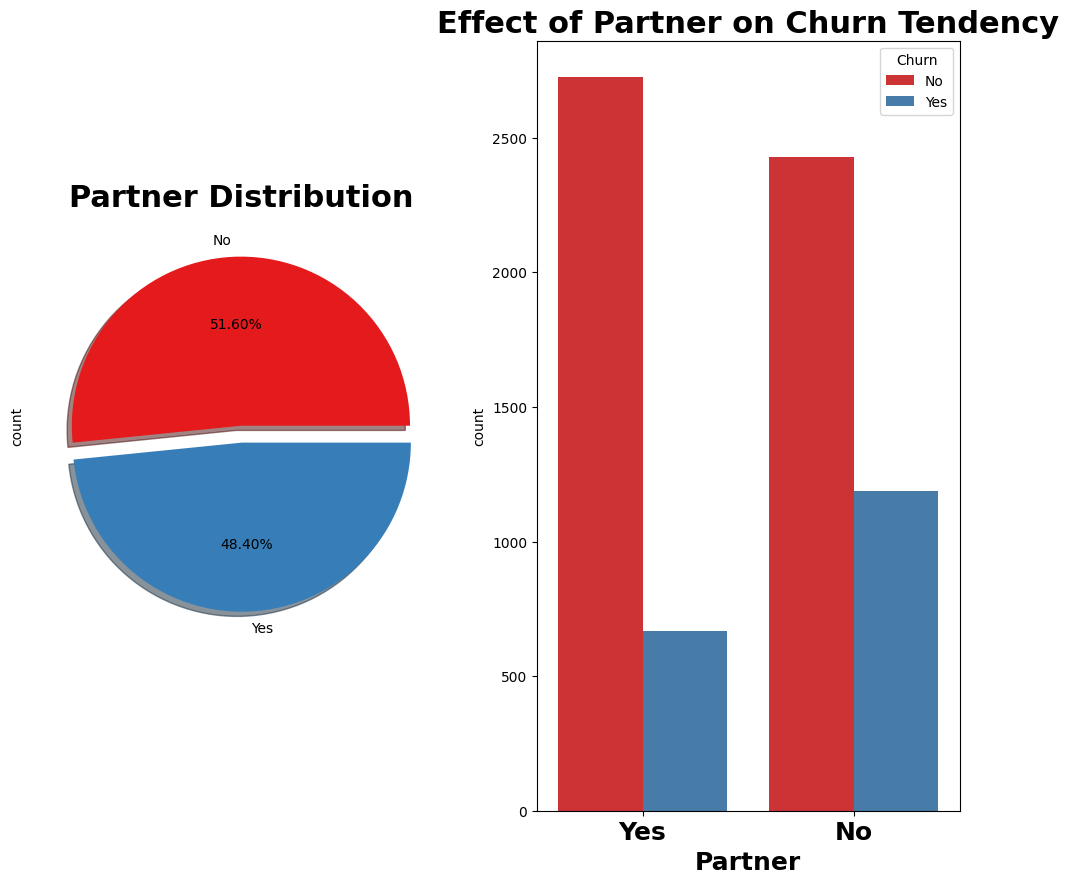

In [ ]:
#Effect of partner and dependent on churn
#senior citizen vs churn
sns.set_palette('Set1')
plt.figure(figsize=(12,10))
plt.subplot(1,2,1)
df['Partner'].value_counts().plot.pie(explode=[0,0.1],autopct='%1.2f%%',shadow=True)
plt.title('Partner Distribution',fontsize=22,fontweight='bold')
plt.subplot(1,2,2)
sns.countplot(x='Partner',hue='Churn',data=df)
plt.title('Effect of Partner on Churn Tendency',fontsize=22,fontweight='bold')
plt.xlabel('Partner',fontsize=18,fontweight='bold')
plt.xticks(fontsize=18,fontweight='bold')
plt.show()

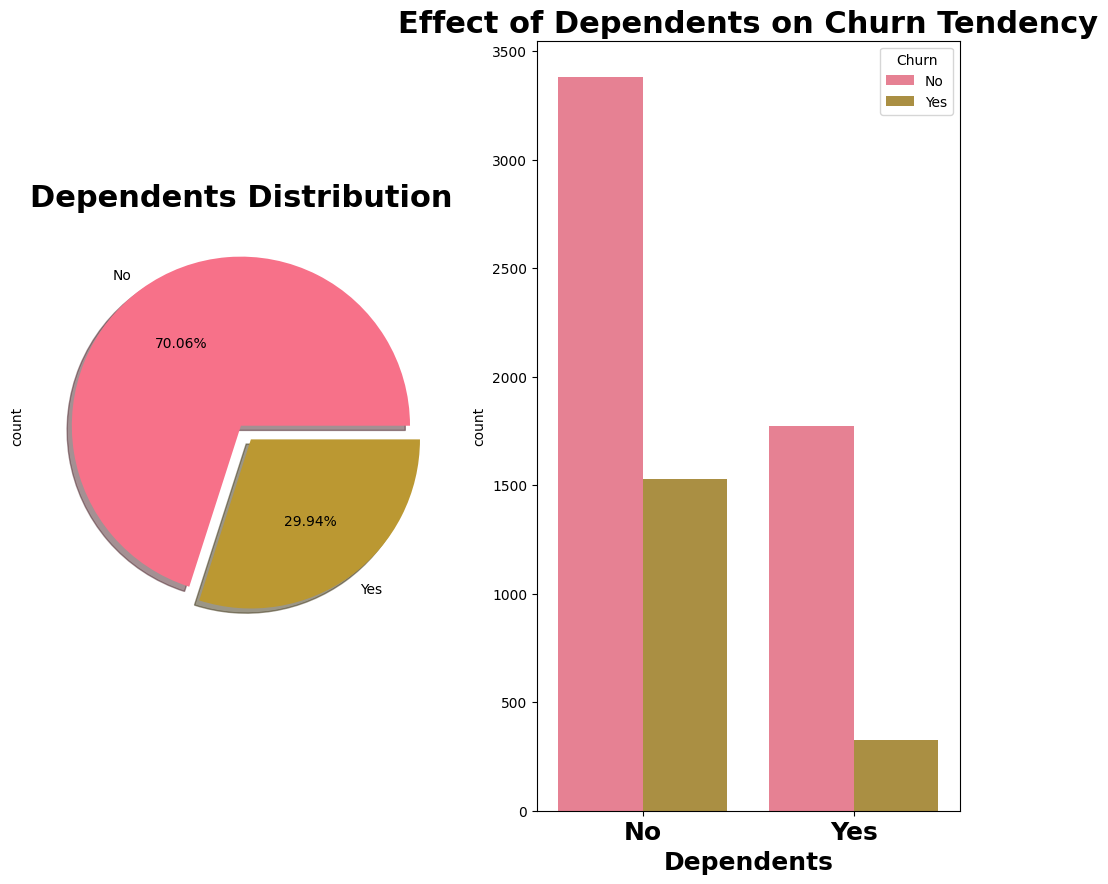

In [ ]:
#dependent vs churn
sns.set_palette('husl')
plt.figure(figsize=(12,10))
plt.subplot(1,2,1)
df['Dependents'].value_counts().plot.pie(explode=[0,0.1],autopct='%1.2f%%',shadow=True)
plt.title('Dependents Distribution',fontsize=22,fontweight='bold')
plt.subplot(1,2,2)
sns.countplot(x='Dependents',hue='Churn',data=df)
plt.title('Effect of Dependents on Churn Tendency',fontsize=22,fontweight='bold')
plt.xlabel('Dependents',fontsize=18,fontweight='bold')
plt.xticks(fontsize=18,fontweight='bold')
plt.show()

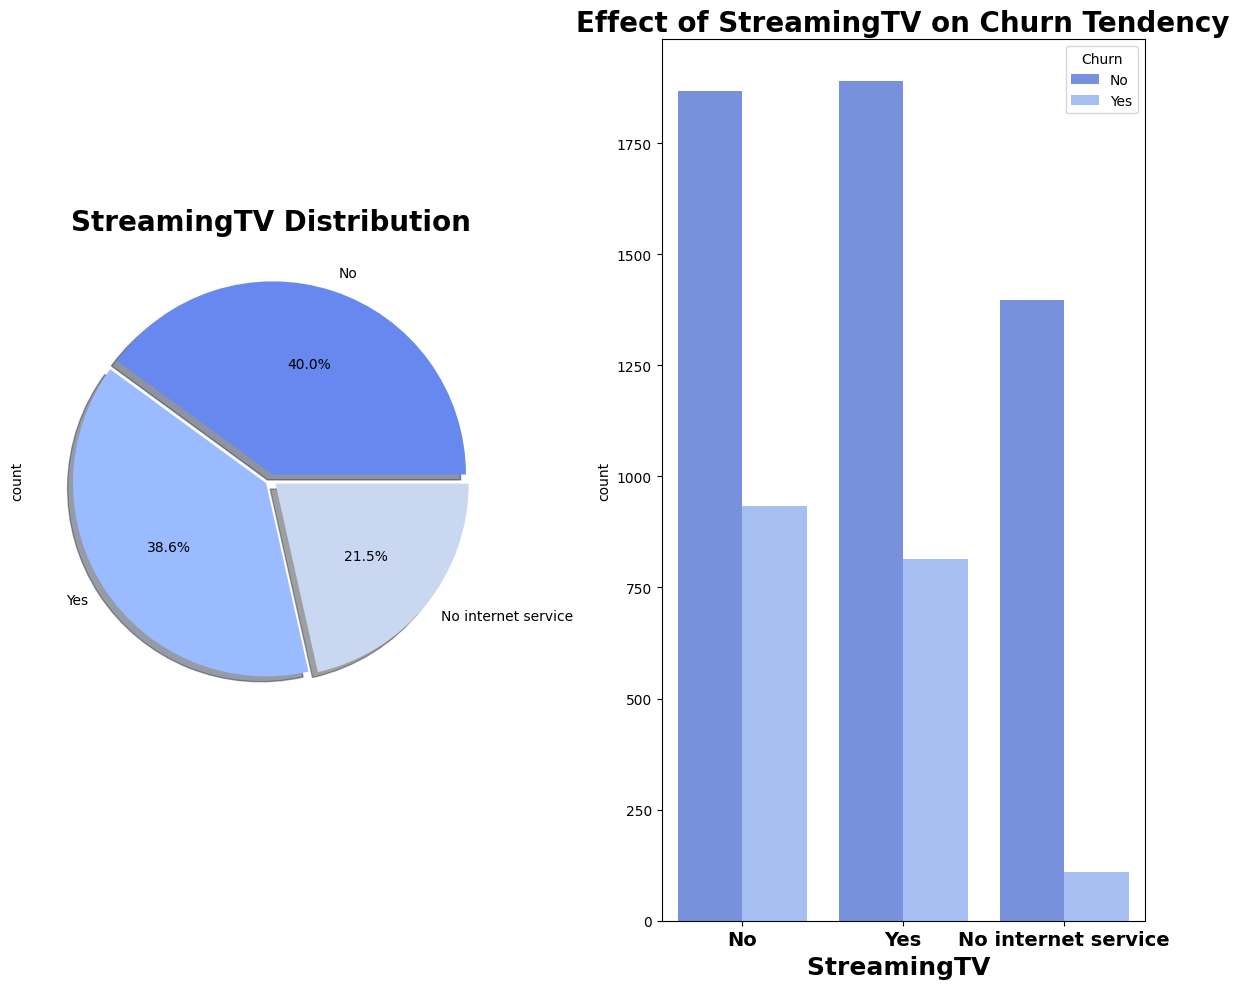

In [ ]:
sns.set_palette('coolwarm')
plt.figure(figsize=(12,10))
plt.subplot(1,2,1)
df['StreamingTV'].value_counts().plot.pie(explode=[0.03,0.03,0.03],
                                          autopct='%2.1f%%',shadow=True)
plt.title('StreamingTV Distribution', fontsize=20,fontweight ='bold')
plt.subplot(1,2,2)
sns.countplot(x='StreamingTV',hue="Churn",data=df)
plt.title('Effect of StreamingTV on Churn Tendency',fontsize=20,fontweight ='bold')
plt.xlabel("StreamingTV ",fontsize=18,fontweight ='bold')
plt.xticks(fontsize=14,fontweight ='bold')
plt.tight_layout()
plt.show()

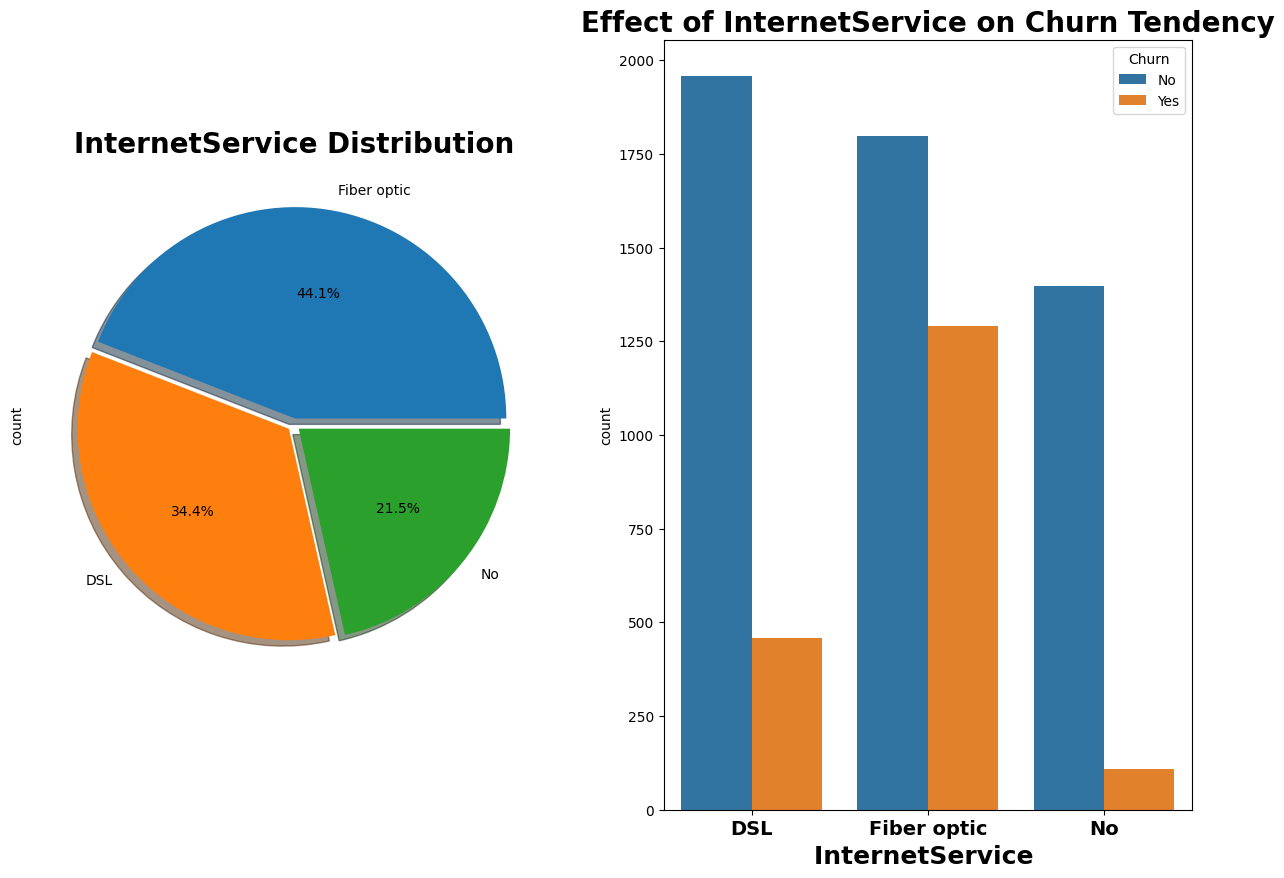

In [ ]:
sns.set_palette('tab10')
plt.figure(figsize=(15,10))
plt.subplot(1,2,1)
df['InternetService'].value_counts().plot.pie(explode=[0.03,0.03,0.03],autopct='%2.1f%%',
                                          shadow=True)
plt.title('InternetService Distribution', fontsize=20,fontweight ='bold')
plt.subplot(1,2,2)
sns.countplot(x='InternetService',hue="Churn",data=df)
plt.title('Effect of InternetService on Churn Tendency',fontsize=20,fontweight ='bold')
plt.xlabel("InternetService ",fontsize=18,fontweight ='bold')
plt.xticks(fontsize=14,fontweight ='bold')
plt.show()

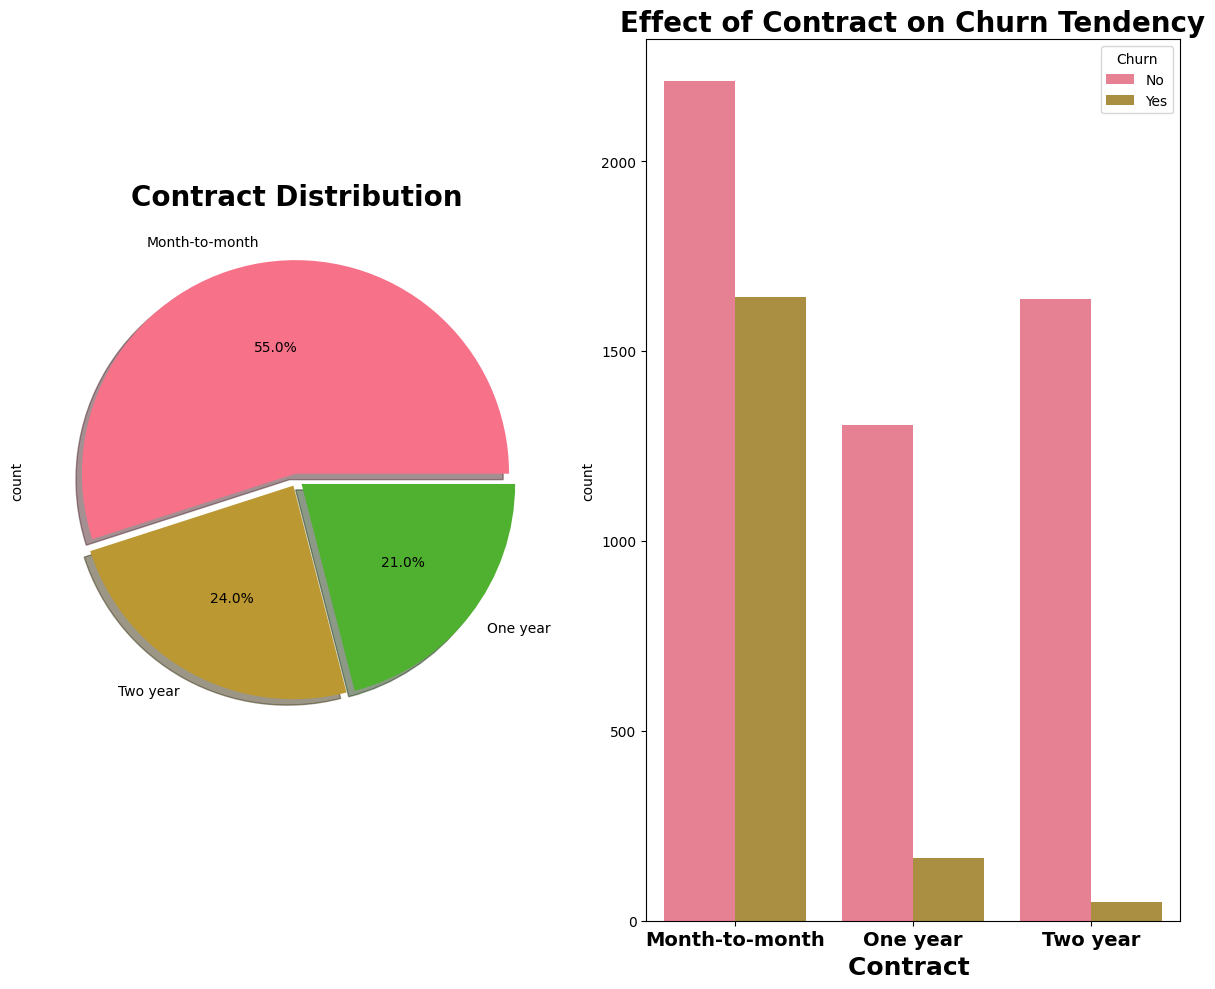

In [ ]:
sns.set_palette('husl')
plt.figure(figsize=(12,10))
plt.subplot(1,2,1)
df['Contract'].value_counts().plot.pie(explode=[0.03,0.03,0.03],autopct='%2.1f%%',shadow=True)
plt.title('Contract Distribution', fontsize=20,fontweight ='bold')
plt.subplot(1,2,2)
sns.countplot(x='Contract',hue="Churn",data=df)
plt.title('Effect of Contract on Churn Tendency',fontsize=20,fontweight ='bold')
plt.xlabel("Contract ",fontsize=18,fontweight ='bold')
plt.xticks(fontsize=14,fontweight ='bold')
plt.tight_layout()
plt.show()

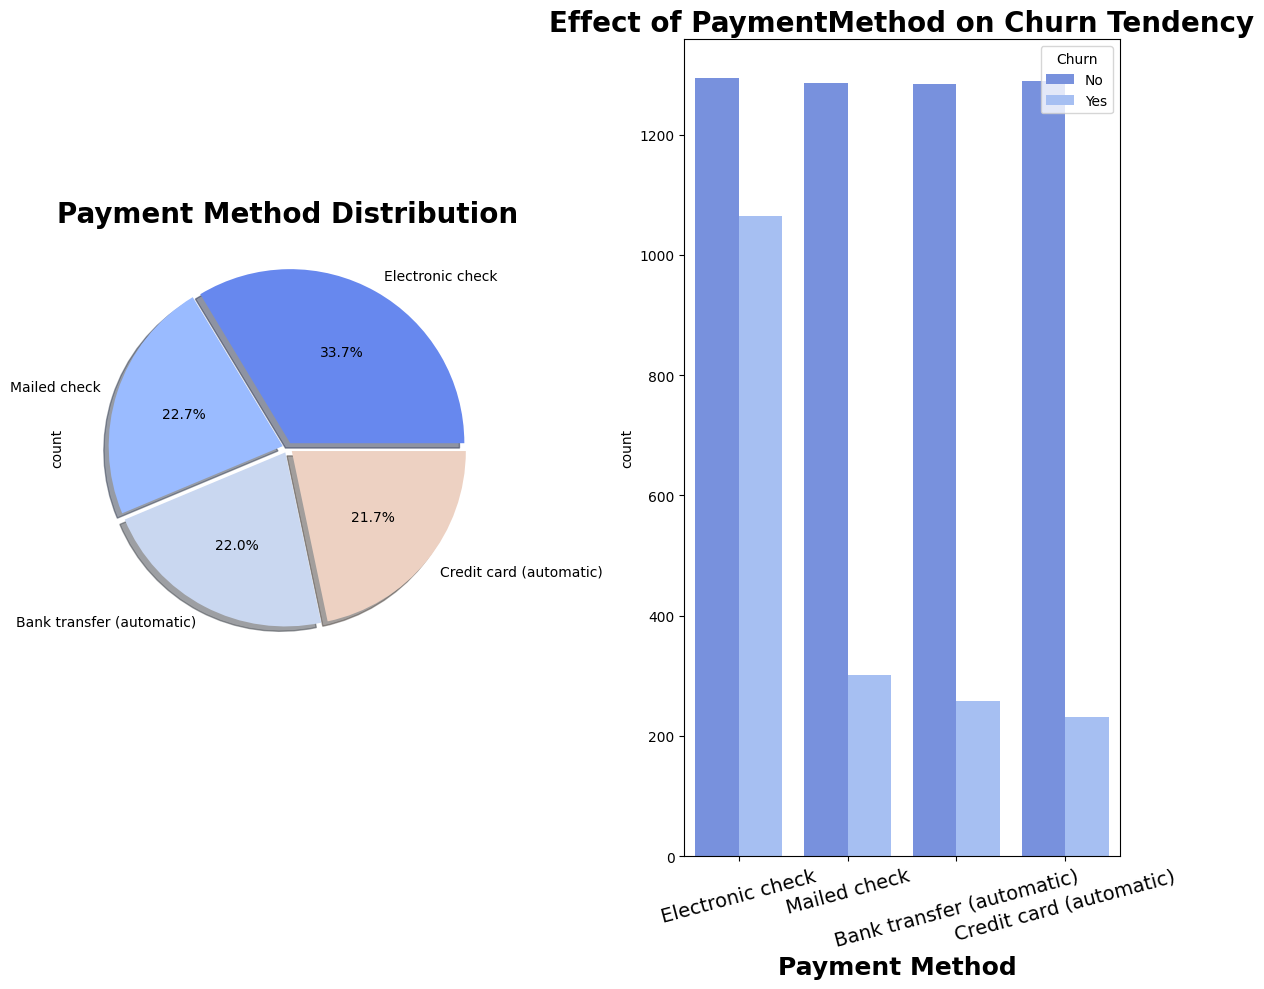

In [ ]:
sns.set_palette('coolwarm')
plt.figure(figsize=(12,10))
plt.subplot(1,2,1)
df['PaymentMethod'].value_counts().plot.pie(explode=[0.03,0.03,0.03,0.03],autopct='%2.1f%%',shadow=True)
plt.title('Payment Method Distribution',fontsize=20,fontweight='bold')
plt.subplot(1,2,2)
sns.countplot(x='PaymentMethod',hue="Churn",data=df)
plt.title('Effect of PaymentMethod on Churn Tendency',fontsize=20,fontweight ='bold')
plt.xlabel("Payment Method ",fontsize=18,fontweight ='bold')
plt.xticks(fontsize=14,rotation=15)
plt.tight_layout()
plt.show()